In [1]:
#Número al azar (random) de 6 números en pantalla tipo loto

import pandas as pd
import numpy as np

np.random.seed(42)
n = 500
df = pd.DataFrame({
    'edad': np.random.randint(18, 70, n),
    'visitas_mes': np.random.randint(0, 20, n),
    'minutos_web': np.random.randint(1, 60, n),
    'tiene_cupon': np.random.randint(0, 2, n)
})


import random
numeros = random.sample(range(1, 66), 6)
print(numeros)
print("Tus 6 numeros son :", numeros)


[32, 40, 13, 61, 36, 62]
Tus 6 numeros son : [32, 40, 13, 61, 36, 62]


In [5]:
#Ejercicio 1: Métricas de evaluación - Ejemplo correo spam

#Importaos numpy, la libreria para trabajar con listas de números (arreglos)
import numpy as np
# Importamos las funciones que calculan las métricas de clasificación
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix

# La verdad: 1 el correo Si es spam, 0= No es spam (10 correos)
reales = np.array([1,0,1,1,0,0,1,0,0,0])
# Lo que respondió el modelo para los mismos correos
predichos = np.array([1,0,0,1,0,1,1,0,0,0])
# Recorremos los correos uno por uno : enumera los numeros = 1
for i, (r, p) in enumerate(zip(reales, predichos), start=1):
    # si la respuesta real y la del modelo coinciden, es acierto; si no es error
    marca = "✓" if r == p else "X"
    # Mostramos en pantalla
    print(f"Correo {i:2}: real={r}  modelo={p}  {marca}")

#Imprimir la matriz de confusión: Filas
#orden [[VN  FP]]
#[FN VP]
print(confusion_matrix(reales, predichos))

#Exactitud: Aciertos/Desaciertos de 10
print ("Exactitud: ", accuracy_score(reales, predichos))
#Precisión de las 4 veces que dijo "Spam", cuantas acertó
print("Precisión: ", precision_score(reales, predichos))
#Recall (sensibilidad) de los 4 correos "Spam" reales, cuantas encontró
print("Recall: ", recall_score(reales, predichos))



Correo  1: real=1  modelo=1  ✓
Correo  2: real=0  modelo=0  ✓
Correo  3: real=1  modelo=0  X
Correo  4: real=1  modelo=1  ✓
Correo  5: real=0  modelo=0  ✓
Correo  6: real=0  modelo=1  X
Correo  7: real=1  modelo=1  ✓
Correo  8: real=0  modelo=0  ✓
Correo  9: real=0  modelo=0  ✓
Correo 10: real=0  modelo=0  ✓
[[5 1]
 [1 3]]


In [8]:
# Parte B- Error de Regresión
# importamos las funciones que calculan el error en regresión
from sklearn.metrics import mean_absolute_error, mean_squared_error

#ventas reales de la cafeteria durante 5 dias
ventas_reales = np.array([100,120,90,150,130])
#ventas que habia predicho l modelo para esos mismos días
ventas_predichas = np.array([110,115,100,140,135])

#np.abs quita el signo : asi vemos por cuanto falló el modelo cada día
print("Errores de cada día: ", np.abs(ventas_reales - ventas_predichas))
#MAE (error absoluto medio): el promedio de esos errores sin signo
print ("MAE: ", mean_absolute_error(ventas_reales, ventas_predichas))
#RMSE: raiz (np.sqrt) del error cuadratico medio
print("RMSE :", round(np.sqrt(mean_squared_error(ventas_reales, ventas_predichas)),2))


Errores de cada día:  [10  5 10 10  5]
MAE:  8.0
RMSE : 8.37


Pacientes para entrenar: 398  · para el examen: 171
Malignos en el examen: 64
Accuracy : 0.942
Precisión: 0.982
Recall   : 0.859
[[106   1]
 [  9  55]]


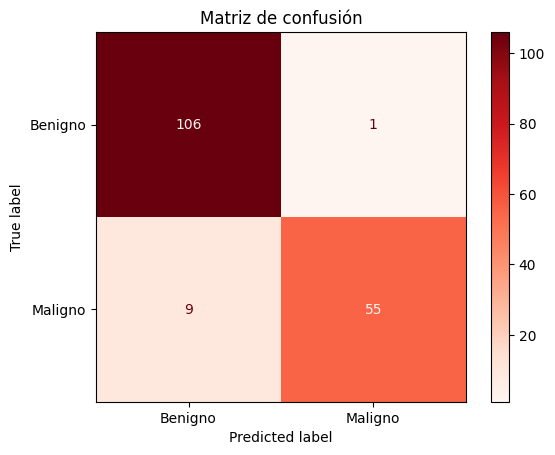

Accuracy del perezoso: 0.626
Recall del perezoso:  0.0


In [11]:
#Parte C
#Ejemplo de una clínica- Cáncer
# Importamos el conjunto de datos de tumores que ya viene dentro de scikit-learn
from sklearn.datasets import load_breast_cancer
# Importamos la función que separa los datos en práctica (train) y examen (test)
from sklearn.model_selection import train_test_split
# Importamos el modelo de regresión logística (visto en la Unidad 3)
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, recall_score


# Cargamos los datos: 569 pacientes con 30 medidas de cada tumor
datos = load_breast_cancer()
# X = las 30 medidas de cada paciente (variables de entrada)
X = datos.data
# y = lo que queremos predecir; lo cambiamos para que 1 = maligno y 0 = benigno
y = (datos.target == 0).astype(int)

# Separamos: 70 % para practicar y 30 % para el examen
# random_state=42 hace que la división salga siempre igual
# stratify=y mantiene la misma proporción de malignos en práctica y examen
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
# Mostramos cuántos pacientes quedaron en cada grupo
print("Pacientes para entrenar:", len(X_train), " · para el examen:", len(X_test))
# Contamos cuántos tumores malignos (unos) hay en el examen
print("Malignos en el examen:", y_test.sum())

# Creamos el modelo; max_iter=5000 le da tiempo suficiente para terminar de aprender
modelo = LogisticRegression(max_iter=5000)
# fit = entrenar: el modelo aprende con los datos de práctica
modelo.fit(X_train, y_train)
# predict = predecir: el modelo responde el examen
pred = modelo.predict(X_test)

# Calculamos las tres métricas; round deja 3 decimales
# Accuracy (exactitud): porcentaje de pacientes bien clasificados
print("Accuracy :", round(accuracy_score(y_test, pred), 3))
# Precisión: cuando dijo "maligno", ¿cuántas veces acertó?
print("Precisión:", round(precision_score(y_test, pred), 3))
# Recall (sensibilidad): de los tumores malignos reales, ¿cuántos encontró?
print("Recall   :", round(recall_score(y_test, pred), 3))
# Imprimimos la matriz de confusión del examen
print(confusion_matrix(y_test, pred))

# Importamos matplotlib para hacer gráficos
import matplotlib.pyplot as plt
# Importamos la herramienta que dibuja la matriz de confusión con colores
from sklearn.metrics import ConfusionMatrixDisplay

# Dibujamos la matriz; display_labels pone nombres en lugar de 0 y 1; cmap elige los colores
ConfusionMatrixDisplay.from_predictions(y_test, pred, display_labels=["Benigno", "Maligno"], cmap="Reds")
# Le ponemos un título al gráfico
plt.title("Matriz de confusión")
# Mostramos el gráfico
plt.show()

# La trampa del accuracy
# el "modelo perezoso": np.zeros crea una lista de puros ceros = siempre dice "benigno"
pred_perezoso = np.zeros(len(y_test), dtype= int)
#su accuracy parece aceptable
print("Accuracy del perezoso:" , round(accuracy_score(y_test, pred_perezoso),3))
#... pero su recall es 0; no encuentra ni un solo tumor maligno
print("Recall del perezoso: ", recall_score(y_test, pred_perezoso))

Overfitting (grado 15)     error práctica=0.001   error examen=52.447


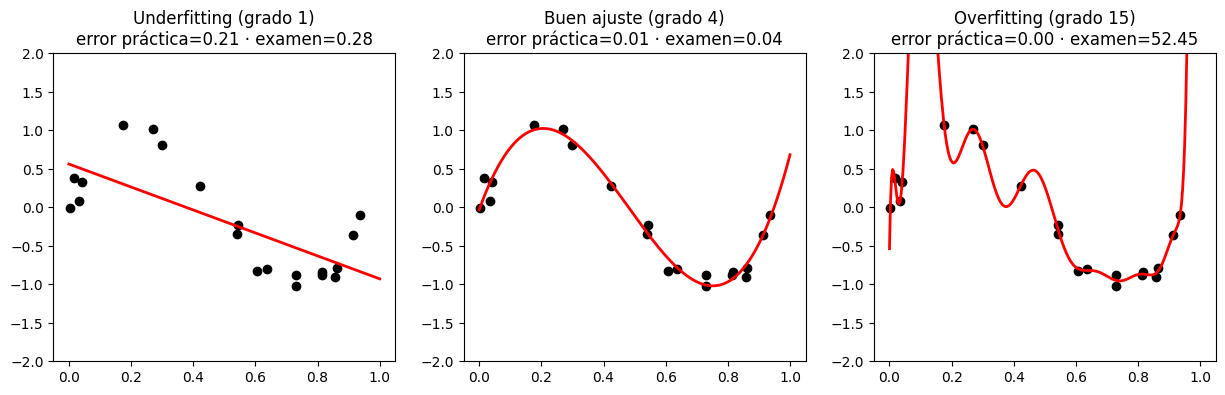

In [12]:
#Ejemplo con:
#Overfitting  (Sobreajuste): cuando el modelo aprende demasiado bien los datos de entrenamiento, memorizando incluso el ruido y los detalles irrelevantes.
#Underfitting (Subajuste): cuando el modelo es demasiado simple para capturar la estructura o los patrones de los datos.

# Importamos numpy para crear números
import numpy as np
# Importamos matplotlib para graficar
import matplotlib.pyplot as plt
# PolynomialFeatures permite hacer curvas (grado 1 = recta, grado alto = curva con muchas vueltas)
from sklearn.preprocessing import PolynomialFeatures
# Regresión lineal, la misma de la Unidad 3
from sklearn.linear_model import LinearRegression
# make_pipeline une dos pasos en uno solo: primero la curva, luego la regresión
from sklearn.pipeline import make_pipeline
# Función para medir el error cuadrático medio
from sklearn.metrics import mean_squared_error
# Creamos un generador de números al azar; la semilla 0 hace que siempre salgan iguales
rng = np.random.default_rng(0)
# 20 valores de x entre 0 y 1, ordenados; reshape los pone en forma de columna
x = np.sort(rng.uniform(0, 1, 20)).reshape(-1, 1)
# y sigue una onda (seno) más un poco de "ruido" al azar
y = np.sin(2 * np.pi * x).ravel() + rng.normal(0, 0.2, 20)

# 50 datos nuevos que el modelo nunca verá al aprender: el "examen"
x_nuevo = np.sort(rng.uniform(0, 1, 50)).reshape(-1, 1)
# Las respuestas correctas de esos 50 datos nuevos, con la misma onda y ruido
y_nuevo = np.sin(2 * np.pi * x_nuevo).ravel() + rng.normal(0, 0.2, 50)

# 300 puntos entre 0 y 1 para dibujar la curva del modelo bien suave
x_linea = np.linspace(0, 1, 300).reshape(-1, 1)
# Creamos una figura ancha para poner 3 gráficos lado a lado
plt.figure(figsize=(15, 4))
# Probamos tres modelos: grado 1, grado 4 y grado 15
for i, (grado, nombre) in enumerate([(1, "Underfitting (grado 1)"), (4, "Buen ajuste (grado 4)"), (15, "Overfitting (grado 15)")]):
    # Creamos el modelo con ese grado y lo entrenamos con los 20 puntos
    modelo = make_pipeline(PolynomialFeatures(grado), LinearRegression()).fit(x, y)
    # Error en la práctica: con los mismos 20 puntos con los que aprendió
    error_practica = mean_squared_error(y, modelo.predict(x))
    # Error en el examen: con los 50 puntos nuevos
    error_examen = mean_squared_error(y_nuevo, modelo.predict(x_nuevo))
    # Elegimos el gráfico número i+1 de los 3
    plt.subplot(1, 3, i + 1)
    # Dibujamos los puntos de práctica en negro
    plt.scatter(x, y, color="black", label="datos de práctica")
    # Dibujamos la curva que aprendió el modelo en rojo
    plt.plot(x_linea, modelo.predict(x_linea), color="red", linewidth=2)
    # Fijamos el eje vertical para que los 3 gráficos se puedan comparar
    plt.ylim(-2, 2)
    # Título con el nombre del modelo y sus dos errores
    plt.title(f"{nombre}\nerror práctica={error_practica:.2f} · examen={error_examen:.2f}")
    # También imprimimos los errores en texto
print(f"{nombre:25}  error práctica={error_practica:.3f}   error examen={error_examen:.3f}")
# Mostramos los 3 gráficos
plt.show()

In [15]:
#Parte A
# Importamos numpy para trabajar con números
import numpy as np
# Conjunto de datos de tumores
from sklearn.datasets import load_breast_cancer
# Función para separar práctica y examen
from sklearn.model_selection import train_test_split
# Modelo de árbol de decisión
from sklearn.tree import DecisionTreeClassifier
#Cargamos los datos
datos = load_breast_cancer()
# X = medidas del tumor y = 1 es maligno, 0 es benigno
X, y = datos.data, (datos.target == 0).astype(int)

#Probamos 5 distintos para rapatir practica y examen
for semilla in [1,2,3,4,5]:
    #Cada semilla reparte a los pacientes de forma diferente
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=semilla)
    #Mismo modelo siempre : arbol de profundidad
    arbol = DecisionTreeClassifier(max_depth=3, random_state=0).fit(X_train, y_train)
    #Mostramos la nota del examen en cada reparto
    print (f"Devision {semilla}: accuracy = {arbol.score(X_test, y_test):.3f}")




Devision 1: accuracy = 0.912
Devision 2: accuracy = 0.924
Devision 3: accuracy = 0.953
Devision 4: accuracy = 0.912
Devision 5: accuracy = 0.953


In [21]:
#Parte B
#importamos numpy
import numpy as np
#Conjunto de datos de tumores
from sklearn.datasets import load_breast_cancer
#funciones para separar los datos y validación cruzada
from sklearn.model_selection import train_test_split, cross_val_score

#cargamos los datos
datos = load_breast_cancer()
#X= medidas del tumor; y=1 si es benigno
X,y = datos.data, (datos.target == 0).astype(int)
#Separamos práctica (70%) y exámen final (30%); el exámen NO se toca hasta el final
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
#Creamos una función para no repetir codigo: calcula la nota de un modelo
def nota_cv(modelo):
  #validación cruzada de 5 pliegues SOLO con los datos de práctica.mean () =promedio
  return cross_val_score(modelo, X_train, y_train, cv=5, scoring="accuracy").mean()
  #escalado de variables
  #La columna 4 es la suavidad del tumor: numeros muy pequeños
print("Rango de 'mean smoothness:" , X[:, 4].min(). round(3), "a", X[:, 4].max().round(3))
  #La columna 3 es el area del tumor: números muy grandes
print("Rango de 'mean area'    :" , X[:, 3].min(). round(1), "a", X[:, 3].max().round(1))


# KNN = K vecinos más cercanos: decide mirando a los pacientes más parecidos
from sklearn.neighbors import KNeighborsClassifier
# StandardScaler pone todas las variables en la misma escala
from sklearn.preprocessing import StandardScaler
# make_pipeline une el escalado y el modelo en un solo paso
from sklearn.pipeline import make_pipeline

# KNN sin escalar: las variables grandes pesan mucho más
knn_sin_escalar = KNeighborsClassifier()
# KNN con escalado: primero escala, luego aplica KNN
knn_escalado = make_pipeline(StandardScaler(), KNeighborsClassifier())

# Nota con validación cruzada del KNN sin escalar
print(f"KNN sin escalar: {nota_cv(knn_sin_escalar):.3f}")
# Nota con validación cruzada del KNN escalado, para comparar
print(f"KNN escalado   : {nota_cv(knn_escalado):.3f}")

#Ajustar las perillas
# Árbol de decisión
from sklearn.tree import DecisionTreeClassifier
# GridSearchCV = búsqueda en rejilla con validación cruzada
from sklearn.model_selection import GridSearchCV

# Primero, un árbol con la configuración por defecto (sin ajustar)
arbol_normal = DecisionTreeClassifier(random_state=42)
# Su nota con validación cruzada
print(f"Árbol sin ajustar: {nota_cv(arbol_normal):.3f}")
# Las "perillas" (hiperparámetros) y los valores que queremos probar
perillas = {
    # Profundidad máxima: cuántas preguntas seguidas puede hacer (None = sin límite)
    "max_depth": [2, 3, 4, 5, 6, 8, None],
    # Mínimo de pacientes que debe haber en cada hoja final del árbol
    "min_samples_leaf": [1, 5, 10, 20],
    # Fórmula que usa el árbol para elegir la mejor pregunta
    "criterion": ["gini", "entropy"],
}
# Preparamos la búsqueda: probará las 7 × 4 × 2 = 56 combinaciones con 5 pliegues cada una
busqueda = GridSearchCV(DecisionTreeClassifier(random_state=42), perillas, cv=5, scoring="accuracy")
# Ejecutamos la búsqueda con los datos de práctica
busqueda.fit(X_train, y_train)

# best_params_ = la mejor combinación encontrada
print("Mejores perillas:", busqueda.best_params_)
# best_score_ = la nota de esa mejor combinación
print(f"Árbol ajustado   : {busqueda.best_score_:.3f}")

#Random Forest = bosque aleatorio
from sklearn.ensemble import RandomForestClassifier
#Creamos un bosque de 200 árboles
bosque = RandomForestClassifier(n_estimators=200, random_state=42)
#Nota con validación cruzada
print(f"Bosque sin ajustar: {nota_cv(bosque):.3f}")

Rango de 'mean smoothness: 0.053 a 0.163
Rango de 'mean area'    : 143.5 a 2501.0
KNN sin escalar: 0.930
KNN escalado   : 0.970
Árbol sin ajustar: 0.917
Mejores perillas: {'criterion': 'entropy', 'max_depth': 6, 'min_samples_leaf': 5}
Árbol ajustado   : 0.940
Bosque sin ajustar: 0.950
